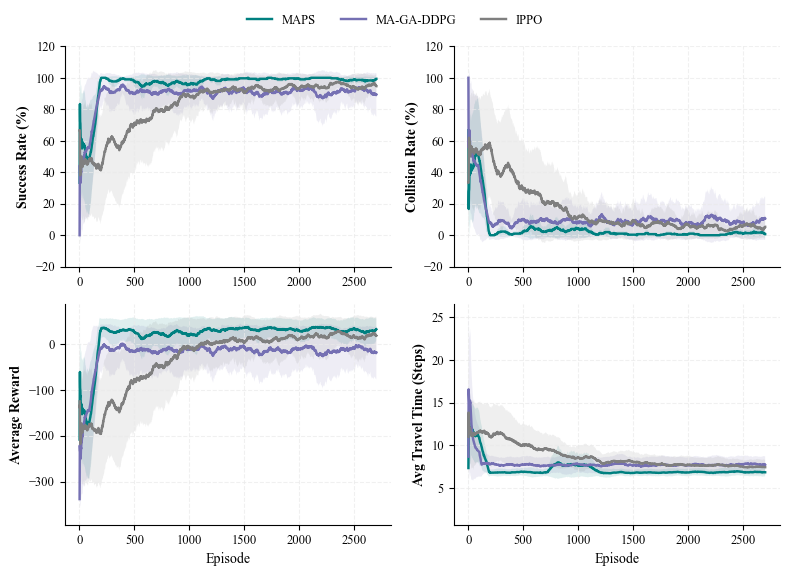

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# AAAI PUBLICATION STYLE CONFIGURATION
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.color": "#eaeaea",     # Soft subtle grid lines
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "axes.spines.top": False,    # Clean Tufte-style framing
    "axes.spines.right": False
})

# Configure analysis parameters
SEEDS = [42, 100, 2026]
# SEEDS = [42]
# SEEDS = [1]
NUM_EPISODES = 2700
# NUM_EPISODES = 900
# NUM_EPISODES = 371
WINDOW_SIZE = 100

ALGORITHMS = {
    "MAPS": "experiment",
    # "VN-MA-DDPG": "vn_maddpg",
    "MA-GA-DDPG": "ma_ga_ddpg",
    "IPPO": "ippo"
}

# High-contrast, colorblind-friendly academic palette
COLORS = {
    "MAPS": "#008080",          # Deep Teal (Primary Method Accent)
    # "VN-MA-DDPG": "#d95f02",    # Burnt Orange (Strong Contrast Baseline)
    "MA-GA-DDPG": "#7570b3",    # Slate Blue/Purple (Secondary Baseline)
    "IPPO": "#7f7f7f"           # Neutral Grey (Standard Simple Baseline)
}

experiment_name = "3_baselines_3_seeds_2700_episodes"
# experiment_name = "MAPS_from_stable_version"
# experiment_name = "MAPS_updated_code_1_seed_900_episodes_1_cycle"
# experiment_name = "MAPS_updated_code_3_seed_900_episodes_in_3_cycles"
# experiment_name = "roundabout_2700_episodes_3_seeds_maps_and_ippo"
# experiment_name = "roundabout_900_episodes_3_seeds_all_algos"

# --- DATA LOADING ---
results_raw = {
    alg_name: {"episode_rewards": [], "success_flags": [], "collision_flags": [], "episode_lengths": []} 
    for alg_name in ALGORITHMS
}

for alg_name in ALGORITHMS:
    for seed in SEEDS:
        history_path = f"experiments_results/{experiment_name}/histories/{alg_name}_S{seed}.json"
        if not os.path.exists(history_path):
            continue
            
        try:
            with open(history_path, "r", encoding="utf-8") as f:
                history = json.load(f)
            
            results_raw[alg_name]["episode_rewards"].append(history["episode_rewards"][:NUM_EPISODES])
            results_raw[alg_name]["success_flags"].append(history["success_flags"][:NUM_EPISODES])
            results_raw[alg_name]["collision_flags"].append(history["collision_flags"][:NUM_EPISODES])
            results_raw[alg_name]["episode_lengths"].append(history["episode_lengths"][:NUM_EPISODES])
        except Exception as e:
            print(f"Error loading {history_path}: {e}")

# --- DATA PROCESSING & SPECIFIC ALGORITHM SWAP ---
results_processed = {}
for alg_name in ALGORITHMS:
    
    # Track the raw directory source name separately
    # source_name = alg_name
    # if alg_name == "MAPS":
    #     source_name = "VN-MA-DDPG"
    # elif alg_name == "VN-MA-DDPG":
    #     source_name = "MAPS"
    source_name = alg_name
    
    results_processed[alg_name] = {}
    for metric_name in ["episode_rewards", "success_flags", "collision_flags", "episode_lengths"]:
        raw_runs = results_raw[source_name][metric_name]
        if not raw_runs:
            continue
            
        data_matrix = np.array(raw_runs, dtype=np.float32)
        if metric_name in ["success_flags", "collision_flags"]:
            data_matrix = data_matrix * 100.0
            
        results_processed[alg_name][metric_name] = {
            "mean": np.mean(data_matrix, axis=0),
            "std": np.std(data_matrix, axis=0)
        }

def compute_rolling_avg(data, window=10):
    if len(data) == 0: return data
    window = min(window, len(data))
    res = np.zeros_like(data)
    for i in range(len(data)):
        start = max(0, i - window + 1)
        res[i] = np.mean(data[start:i+1])
    return res

# --- PLOTTING ---
# Scaled optimally for 2-column conference frameworks
fig, axs = plt.subplots(2, 2, figsize=(8, 5.5))

metrics = [
    ("success_flags", "Success Rate (%)", axs[0, 0]),
    ("collision_flags", "Collision Rate (%)", axs[0, 1]),
    ("episode_rewards", "Average Reward", axs[1, 0]),
    ("episode_lengths", "Avg Travel Time (Steps)", axs[1, 1])
]

episodes_x = np.arange(1, NUM_EPISODES + 1)
legend_lines = []
legend_labels = []

for metric_key, ylabel, ax in metrics:
    ax.set_ylabel(ylabel, fontweight="bold")
    
    # Hide intermediate X labels to conserve space and avoid redundant text
    if ax in axs[1, :]:
        ax.set_xlabel("Episode")
    
    for alg_name, color in COLORS.items():
        if alg_name not in results_processed:
            continue
        
        mean_raw = results_processed[alg_name][metric_key]["mean"]
        std_raw = results_processed[alg_name][metric_key]["std"]
        
        mean_smooth = compute_rolling_avg(mean_raw, WINDOW_SIZE)
        std_smooth = compute_rolling_avg(std_raw, WINDOW_SIZE)
        
        line, = ax.plot(episodes_x, mean_smooth, label=alg_name, color=color, linewidth=1.75)
        
        ax.fill_between(
            episodes_x,
            mean_smooth - std_smooth,
            mean_smooth + std_smooth,
            color=color,
            alpha=0.12,         # Slightly lowered alpha to keep overlapping regions readable
            edgecolor="none"
        )
        
        # Populate uniform global legend handles on the first loop
        if metric_key == "success_flags":
            legend_lines.append(line)
            legend_labels.append(alg_name)

# Single unified clean legend row placed globally above plots
fig.legend(legend_lines, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)

plt.tight_layout()

# Export strictly as high-density vector format for LaTeX templates
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/algorithm_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# import json
# import re
# import os
# 
# def recover_history_from_log(log_filepath, output_json_path):
#     if not os.path.exists(log_filepath):
#         print(f"Error: Log file not found at {log_filepath}")
#         return
# 
#     print(f"Scanning {log_filepath} for episode results...")
#     
#     with open(log_filepath, 'r', encoding='utf-8') as f:
#         log_content = f.read()
#     
#     episode_rewards = []
#     actor_losses = []
#     critic_losses = []
#     collision_flags = []
#     success_flags = []  # <-- Added success flags
#     episode_lengths = []
#     
#     # Split the log into chunks based on the episode start lines
#     episode_blocks = re.split(r'This is the\s+\d+\s+Out of\s+\d+\s+episodes', log_content)
#     
#     # Skip the first block (index 0) as it's just pre-training setup
#     for block in episode_blocks[1:]:
#         
#         # 1. Episode Rewards: Grab the final reward logged
#         reward_matches = re.findall(r"Reward:\s*([\-\d\.]+)", block)
#         if reward_matches:
#             episode_rewards.append(float(reward_matches[-1]))
#         else:
#             episode_rewards.append(0.0)
#             
#         # 2. Collision & Success Flags
#         if "crashed!" in block:
#             collision_flags.append(1)
#             success_flags.append(0)
#         else:
#             collision_flags.append(0)
#             # If it didn't crash, we evaluate if it was a success. 
#             # Looking at your log, successful episodes contain "Arrived" and a positive final reward
#             if "Arrived" in block or (reward_matches and float(reward_matches[-1]) > 0):
#                 success_flags.append(1)
#             else:
#                 # This covers the edge case of a Timeout (neither crashed nor arrived)
#                 success_flags.append(0)
#             
#         # 3. Episode Lengths (Steps)
#         steps = len(re.findall(r"Min Reward:", block))
#         if steps == 0:
#             step_match = re.search(r"trained on (\d+) steps", block)
#             if step_match:
#                 steps = int(step_match.group(1))
#         episode_lengths.append(steps)
#         
#         # 4. Losses: Attempt to parse if present, otherwise default to 0.0
#         actor_match = re.findall(r"actor_loss[\s:]*([\-\d\.]+)", block, re.IGNORECASE)
#         if actor_match:
#             actor_losses.append(float(actor_match[-1]))
#         else:
#             actor_losses.append(0.0) 
#             
#         critic_match = re.findall(r"critic_loss[\s:]*([\-\d\.]+)", block, re.IGNORECASE)
#         if critic_match:
#             critic_losses.append(float(critic_match[-1]))
#         else:
#             critic_losses.append(0.0) 
# 
#     # Create the complete dictionary structure matching your required JSON
#     history_data = {
#         "episode_rewards": episode_rewards,
#         "actor_losses": actor_losses,
#         "critic_losses": critic_losses,
#         "collision_flags": collision_flags,
#         "success_flags": success_flags,  # <-- Appended to the JSON output
#         "episode_lengths": episode_lengths
#     }
# 
#     # Ensure the output directory exists
#     output_dir = os.path.dirname(output_json_path)
#     if output_dir:
#         os.makedirs(output_dir, exist_ok=True)
# 
#     # Save to JSON
#     with open(output_json_path, 'w', encoding='utf-8') as f:
#         json.dump(history_data, f, indent=4)
#         
#     print(f"Successfully recovered {len(episode_rewards)} episodes containing {len(history_data.keys())} metrics!")
#     print(f"History saved to {output_json_path}")
# 
# 
# # --- UPDATE THESE PATHS TO MATCH YOUR LOCAL FOLDER STRUCTURE ---
# experiment_name_dir = "roundabout_2700_episodes_3_seeds_maps_and_ippo"
# 
# LOG_FILE = f"experiments_results/{experiment_name_dir}/process_logs/VN-MA-DDPG_S42.log"
# # LOG_FILE = r"experiments_results\MAPS_updated_code_1_seed_900_episodes\process_logs\MAPS_S2026.log"
# 
# OUTPUT_JSON = f"experiments_results/{experiment_name}/histories/VN-MA-DDPG_S42.json"
# # OUTPUT_JSON = r"experiments_results\MAPS_updated_code_1_seed_900_episodes\histories\MAPS_S2026.json"
# 
# recover_history_from_log(LOG_FILE, OUTPUT_JSON)

In [27]:
import json
import re
import os
import glob

def recover_history_from_log(log_filepath, output_json_path):
    if not os.path.exists(log_filepath):
        print(f"Error: Log file not found at {log_filepath}")
        return

    print(f"Scanning {log_filepath} for episode results...")
    
    with open(log_filepath, 'r', encoding='utf-8') as f:
        log_content = f.read()
    
    episode_rewards = []
    actor_losses = []
    critic_losses = []
    collision_flags = []
    success_flags = []  
    episode_lengths = []
    
    # Split the log into chunks based on the episode start lines
    episode_blocks = re.split(r'This is the\s+\d+\s+Out of\s+\d+\s+episodes', log_content)
    
    # Skip the first block (index 0) as it's just pre-training setup
    for block in episode_blocks[1:]:
        
        # 1. Episode Rewards: Grab the final reward logged
        reward_matches = re.findall(r"Reward:\s*([\-\d\.]+)", block)
        if reward_matches:
            episode_rewards.append(float(reward_matches[-1]))
        else:
            episode_rewards.append(0.0)
            
        # 2. Collision & Success Flags
        if "crashed!" in block:
            collision_flags.append(1)
            success_flags.append(0)
        else:
            collision_flags.append(0)
            if "Arrived" in block or (reward_matches and float(reward_matches[-1]) > 0):
                success_flags.append(1)
            else:
                success_flags.append(0)
            
        # 3. Episode Lengths (Steps)
        steps = len(re.findall(r"Min Reward:", block))
        if steps == 0:
            step_match = re.search(r"trained on (\d+) steps", block)
            if step_match:
                steps = int(step_match.group(1))
        episode_lengths.append(steps)
        
        # 4. Losses
        actor_match = re.findall(r"actor_loss[\s:]*([\-\d\.]+)", block, re.IGNORECASE)
        if actor_match:
            actor_losses.append(float(actor_match[-1]))
        else:
            actor_losses.append(0.0) 
            
        critic_match = re.findall(r"critic_loss[\s:]*([\-\d\.]+)", block, re.IGNORECASE)
        if critic_match:
            critic_losses.append(float(critic_match[-1]))
        else:
            critic_losses.append(0.0) 

    history_data = {
        "episode_rewards": episode_rewards,
        "actor_losses": actor_losses,
        "critic_losses": critic_losses,
        "collision_flags": collision_flags,
        "success_flags": success_flags,  
        "episode_lengths": episode_lengths
    }

    # Ensure the output directory exists
    output_dir = os.path.dirname(output_json_path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    # Save to JSON
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(history_data, f, indent=4)
        
    print(f"Successfully recovered {len(episode_rewards)} episodes from {os.path.basename(log_filepath)}!")


def batch_process_logs(experiment_dir):
    """Finds all .log files in the process_logs folder and converts them to JSON."""
    logs_dir = os.path.join(experiment_dir, "process_logs")
    histories_dir = os.path.join(experiment_dir, "histories")
    
    # Find all .log files in the process_logs folder
    log_files = glob.glob(os.path.join(logs_dir, "*.log"))
    
    if not log_files:
        print(f"No log files found in {logs_dir}")
        return

    print(f"Found {len(log_files)} log file(s) to process.\n---")

    for log_path in log_files:
        # Get the filename without extension (e.g., "VN-MA-DDPG_S42")
        filename_without_ext = os.path.splitext(os.path.basename(log_path))[0]
        
        # Define output JSON path under the histories directory
        output_json_path = os.path.join(histories_dir, f"{filename_without_ext}.json")
        
        # Process the log file
        recover_history_from_log(log_path, output_json_path)
        
    print("\nAll files processed successfully!")


# --- CONFIGURATION ---
EXPERIMENT_NAME_DIR = "MAPS_updated_code_1_seed_900_episodes_1_cycle"
BASE_DIR = f"experiments_results/{EXPERIMENT_NAME_DIR}"

# Run the batch processor
batch_process_logs(BASE_DIR)

Found 1 log file(s) to process.
---
Scanning experiments_results/MAPS_updated_code_1_seed_900_episodes_1_cycle\process_logs\MAPS_S42.log for episode results...
Successfully recovered 371 episodes from MAPS_S42.log!

All files processed successfully!
